## Exploratory Data Analysis

In this document, we perform EDA for our content-based recommender system. It will help us understand the dataset, detect patterns and identify potential problems with data.

### Libraries

In [4]:
import pandas as pd
import sys
import os
from pathlib import Path
import pandas as pd
from wordcloud import WordCloud

### Loading dataset

In [5]:
# Get the current notebook's directory
PROJECT_ROOT = Path(os.getcwd()).parent  # Assuming 'notebooks/' is inside the project root

# Add it to sys.path
sys.path.append(str(PROJECT_ROOT))

# Now you can import your config module
import isa_project_1.config as config

print("opening dataset...")
# here we read the respective output file where the dataset was stored 
movie_df = pd.read_csv(config.INTERIM_DATASETS['tmdb_5000_movies.csv'])
print("success!")

opening dataset...
success!


### First glimpse on dataset

In [6]:
# Check the first few rows
print(movie_df.head())

# Check dataset info
print(movie_df.info())


      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   
2  [{"id": 470, "nam

### Missing values

In [7]:
# Check for missing values
print(movie_df.isnull().sum())

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64


### Distribution of Movie Genre

In this section we examine the distribution of Movie Genres as they are one of the most important predictors. The distribution is also visualized by a plot. This can later influence recommendation strategies.

C:\Users\fmojt\AppData\Local\Temp\ipykernel_123640\4014956659.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette="viridis")


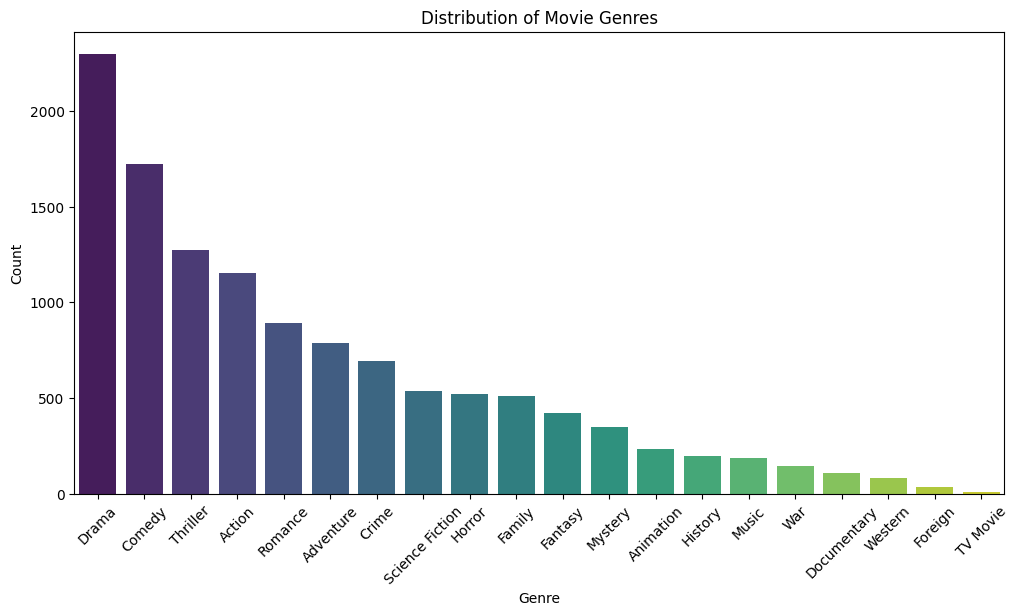

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Convert genre column from string to a list of dictionaries
movie_df["genres"] = movie_df["genres"].apply(lambda x: [d["name"] for d in ast.literal_eval(x)] if pd.notna(x) else [])

# Flatten genres into a list
all_genres = [genre for sublist in movie_df["genres"] for genre in sublist]

# Count occurrences
genre_counts = pd.Series(all_genres).value_counts()

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette="viridis")
plt.xticks(rotation=45)
plt.xlabel("Genre")
plt.ylabel("Count")
plt.title("Distribution of Movie Genres")
plt.show()

### Word frequency

Since we are going to apply TF-IDF on movie descriptions, tagline and keywords, let's **visualize the most frequent words** for each. We'are going to utilize the **Wordcloud** package for that.

In [9]:
def visualize_word_counts(df: pd.DataFrame, column: str):

    # Combine all movie descriptions into one text corpus
    text_corpus = " ".join(df[column].dropna())

    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color="black", colormap="viridis").generate(text_corpus)

    # Plot word cloud
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Most Common Words in Movie {column}")
    plt.show()

#### Overview

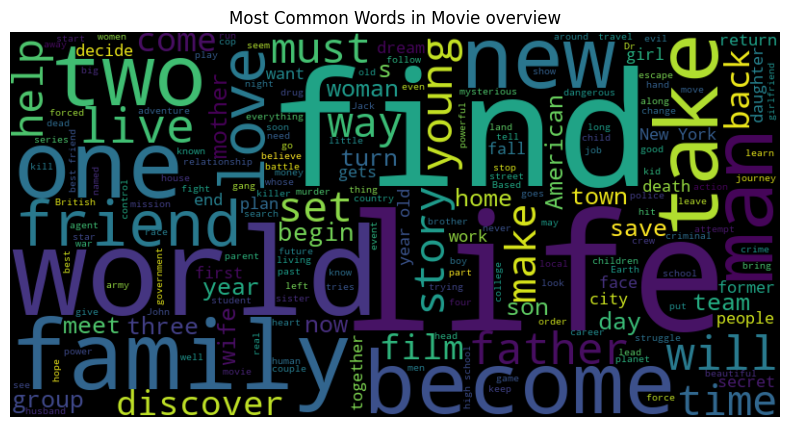

In [10]:
visualize_word_counts(movie_df, "overview")

### Keywords

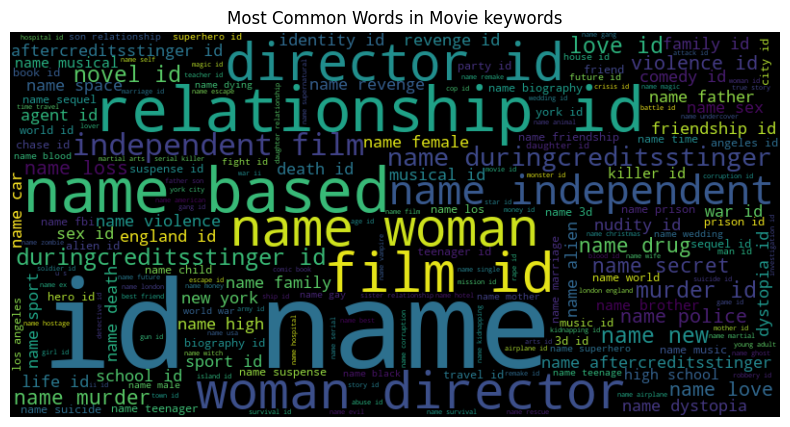

In [11]:
visualize_word_counts(movie_df, "keywords")

#### Tagline

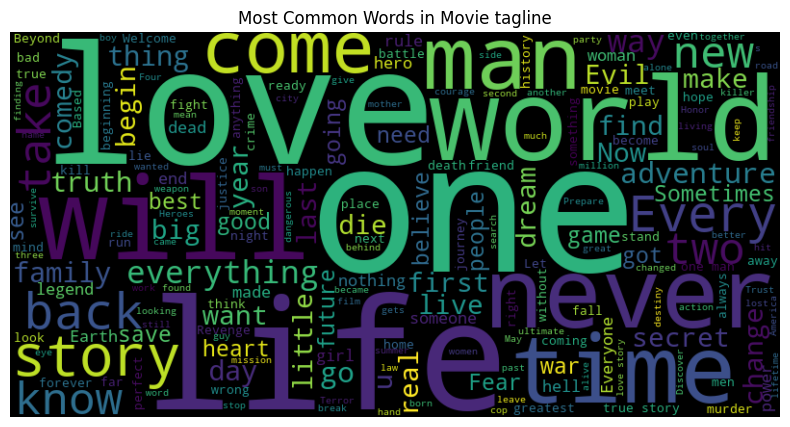

In [12]:
visualize_word_counts(movie_df, "tagline")